# SmartCart: Customer Segmentation

Segmenting retail customers into distinct groups based on spending behaviour, income, and demographics, to support targeted marketing. The workflow covers data cleaning, feature engineering, outlier removal, dimensionality reduction (PCA), and clustering (K-Means and Agglomerative), followed by profiling each resulting segment.

**Dataset:** `smartcart_customers.csv` — 2,240 customers with demographics, purchase history by product category, and campaign response data.

**Tech stack:** pandas, numpy, seaborn/matplotlib, scikit-learn, kneed


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle Missing Values

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Feature Engineering 

In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [11]:
# Age 
df["Age"] = 2026 - df["Year_Birth"]


In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [16]:
# Customer tenure days 

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1529,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,21,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,734,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,48,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,407,1


In [18]:
# Total Spending 
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"]

#Total Children 
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [20]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children'],
      dtype='object')

In [28]:
# Education 
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate", 
    "Graduation": "Graduate", 
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [29]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [31]:
# Merital status 
df["Marital_Status"].value_counts()

df["Couple/Single"] = df["Marital_Status"].replace({
    "Married": "Couple", "Together": "Couple", 
    "Single": "Single", "Divorced": "Single", "Widow": "Single", "Alone": "Single", "Absurd": "Single", "YOLO": "Single"
})

In [32]:
df["Couple/Single"].value_counts()

Couple/Single
Couple    1444
Single     796
Name: count, dtype: int64

### Drop Columns

In [33]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Eduaction', 'Couple/Single'],
      dtype='object')

In [37]:
column = ["ID", "Year_Birth", "Education", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "MntFruits"]

total_col = column + spending_cols

df_cleaned = df.drop(columns=total_col)

In [40]:
df_cleaned.columns


Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Couple/Single'],
      dtype='object')

In [41]:
df_cleaned.shape

(2240, 15)

## Outliers

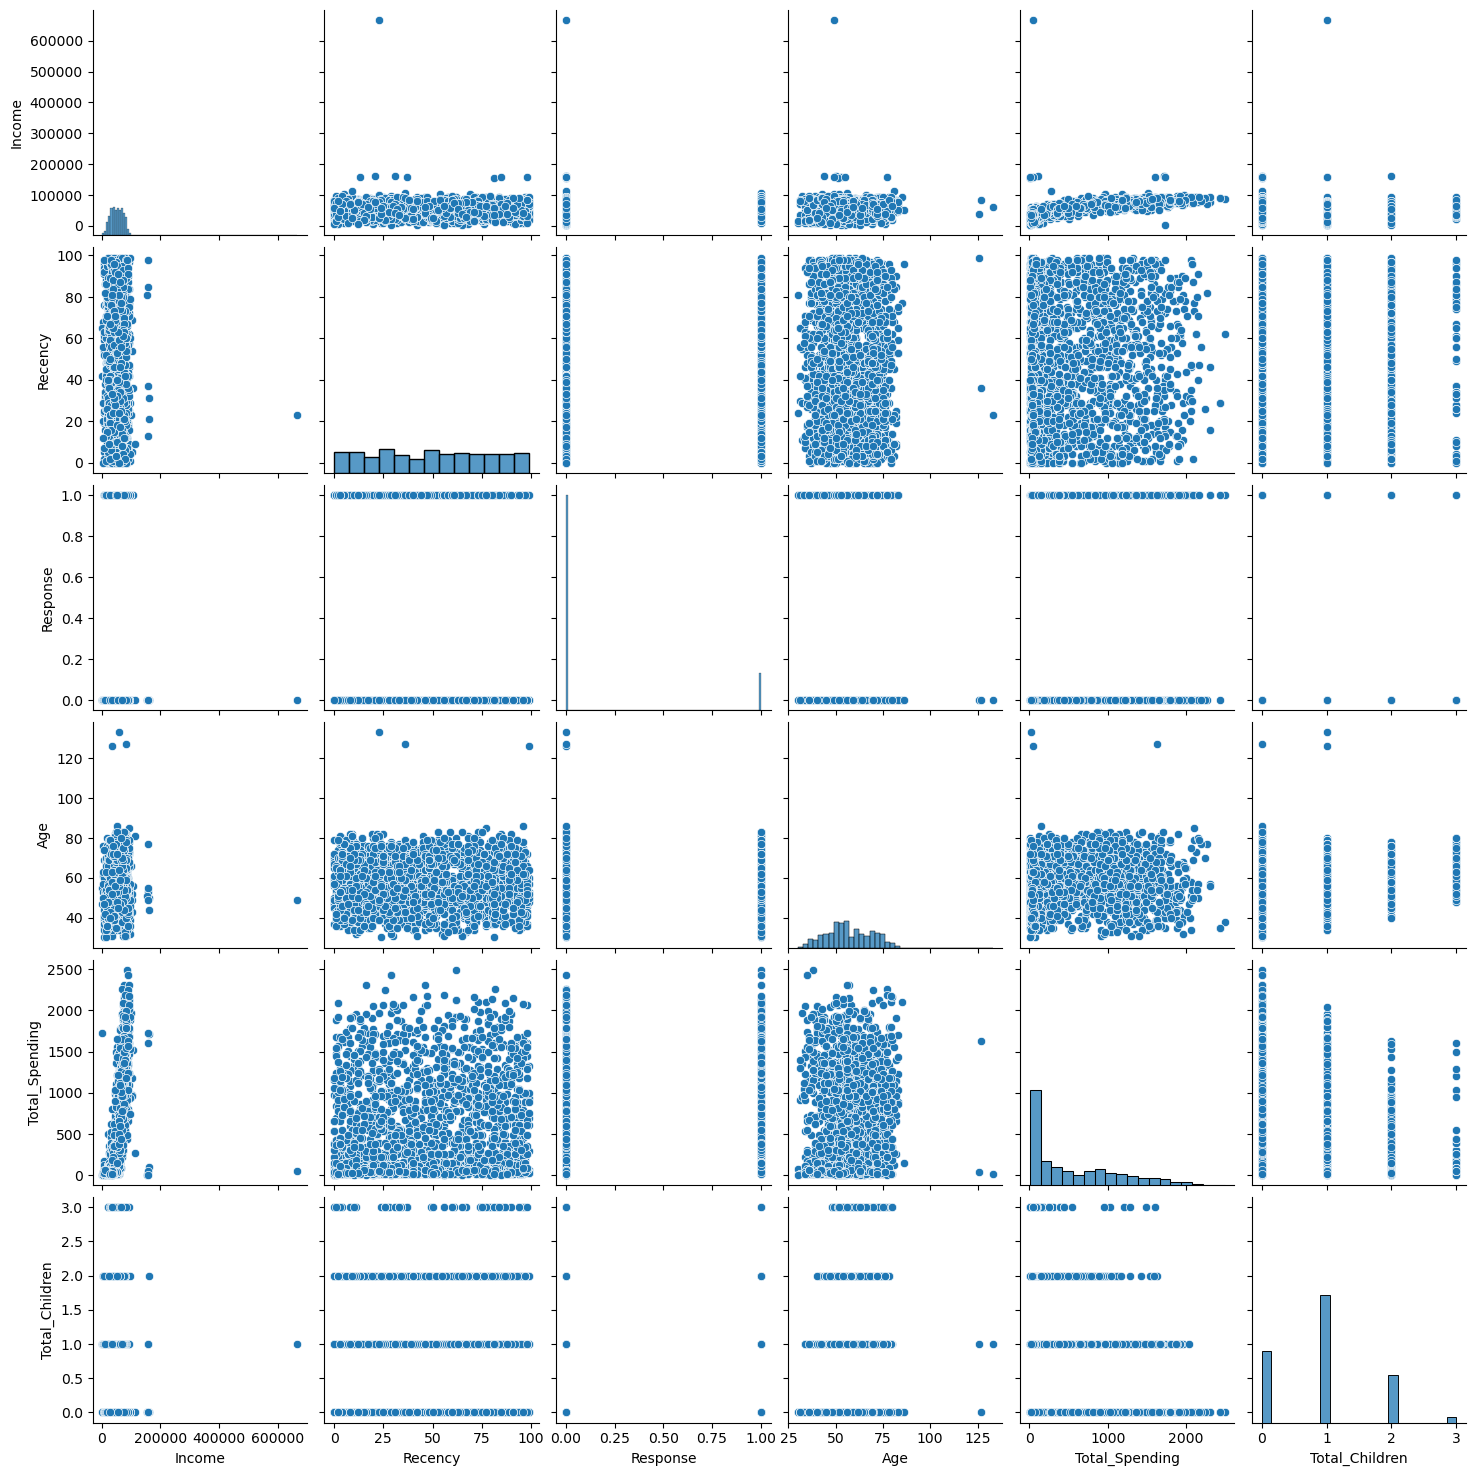

In [43]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Relative plots of sume features 
sns.pairplot(df_cleaned[cols])

In [44]:
# Remove outliers 

print("Data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("Data size without outliers:", len(df_cleaned))

Data size with outliers: 2240
Data size without outliers: 2236


Removing customers older than 90 and incomes above £600k trims 4 extreme outliers from the dataset (2,240 → 2,236 rows), preventing a handful of unrealistic values from distorting the scaling and clustering steps that follow.


### Heatmap

In [45]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

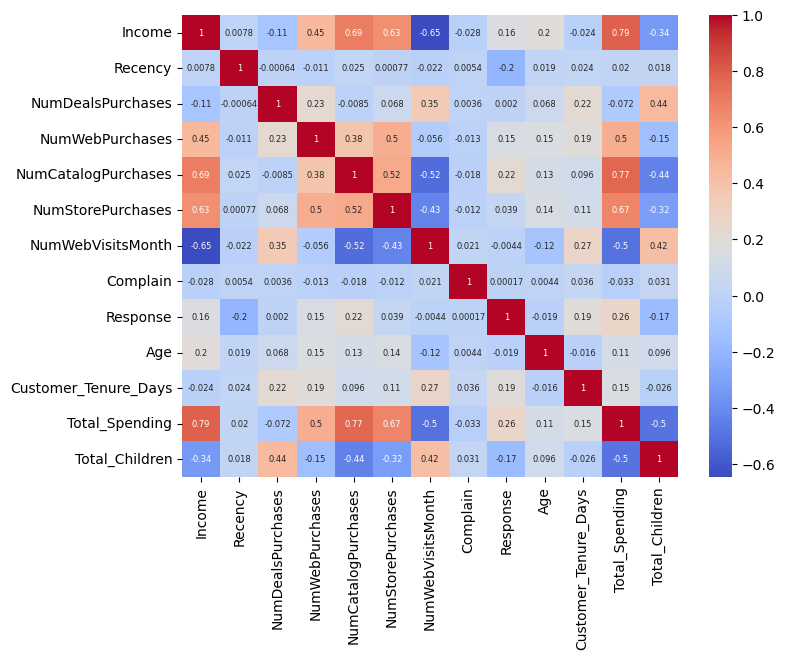

In [49]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr, 
    annot=True, 
    annot_kws={"size": 6},
    cmap="coolwarm"
)



### Encoding

In [50]:
from sklearn.preprocessing import OneHotEncoder

In [52]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Couple/Single"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [54]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [55]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Couple/Single_Couple,Couple/Single_Single
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0


In [57]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [58]:
df_encoded.shape

(2236, 18)

In [59]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Couple/Single_Couple,Couple/Single_Single
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,1.0,0.0,0.0,0.0,1.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,1.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,0.0,1.0,0.0,1.0,0.0


### Scalling

In [60]:
from sklearn.preprocessing import StandardScaler 

X = df_encoded

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Visualize

In [61]:
# 2D 

from sklearn.decomposition import PCA 

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

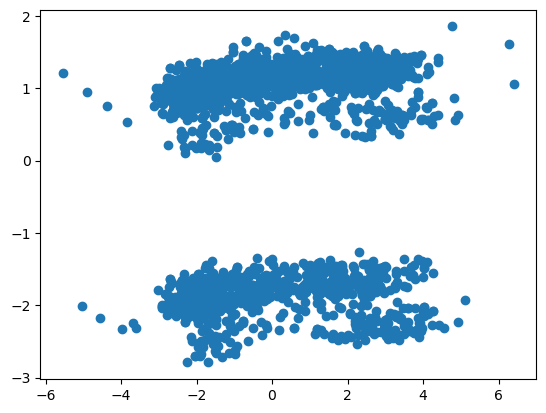

In [62]:
# Plot 
plt.scatter(X_pca[:, 0], X_pca[:, 1])

In [63]:
pca.explained_variance_ratio_

array([0.23125129, 0.11385768])

In [64]:
# 3D 

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [65]:
pca.explained_variance_ratio_

array([0.23125129, 0.11385768, 0.10407016])

Text(0.5, 0.92, '3D Projection')

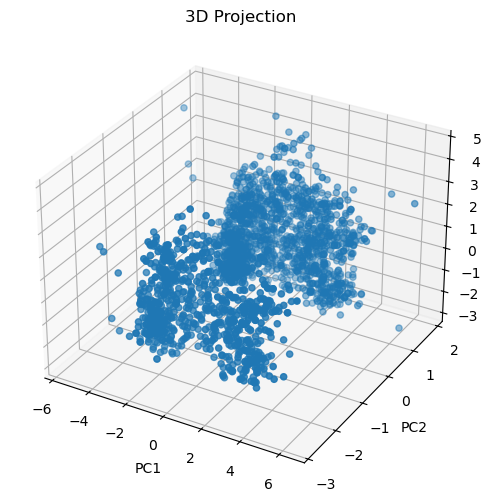

In [66]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

**PCA takeaways:** the first 3 principal components explain about 45% of total variance (23.1% + 11.4% + 10.4%), giving a reasonable 3D projection to cluster on without carrying all the original dimensions.


## Analyze K - Value 

### 1. Elbow Method

In [67]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = [] 
for k in range(1, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [69]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [70]:
print("Best K =", optimal_k)

Best K = 4


Text(0, 0.5, 'wcss')

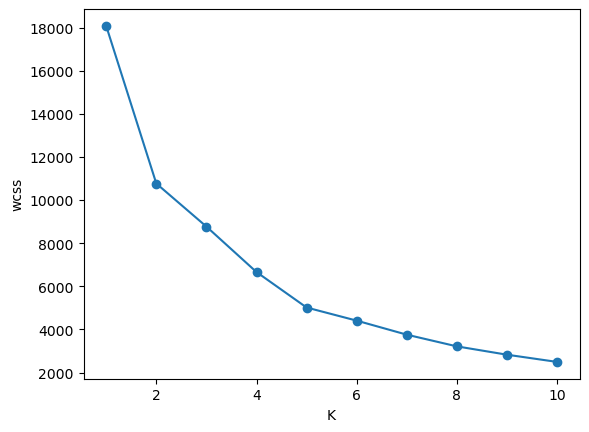

In [71]:
# Plot 

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("wcss")

### 2. Silhouette Score

Text(0, 0.5, 'silhouette score')

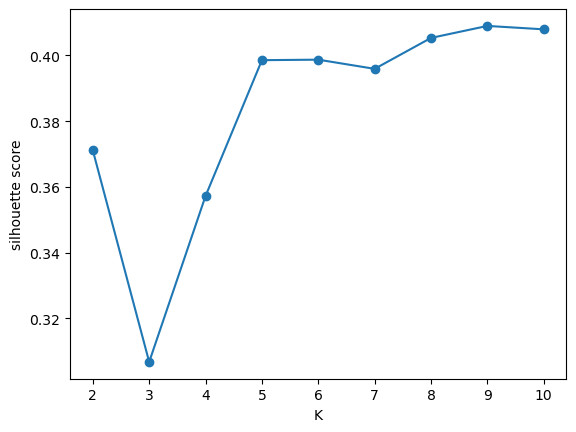

In [74]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot
plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("silhouette score")

Text(0, 0.5, 'Silhouette Score')

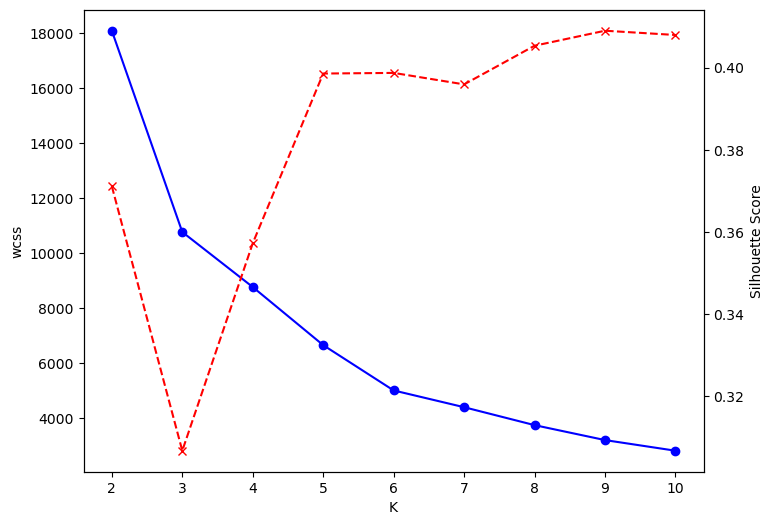

In [79]:
# Combined plot 

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silhouette Score")

**Choosing K:** the elbow method and silhouette score agree on **K = 4**, so both K-Means and Agglomerative Clustering below are run with 4 clusters.


## Clustering

### K_means

In [80]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans  = kmeans.fit_predict(X_pca)

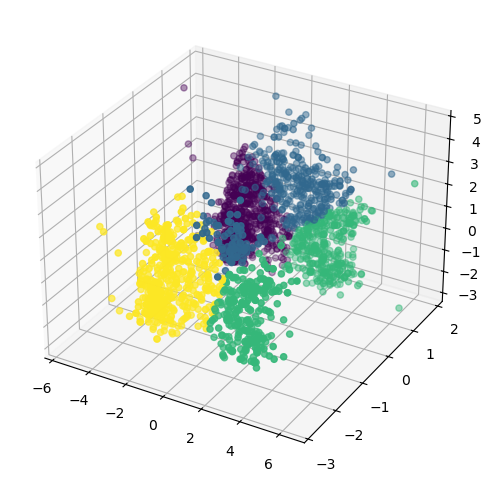

In [82]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

### Agglomerative Clustering

In [83]:
from sklearn.cluster import AgglomerativeClustering

agg_cls = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_cls.fit_predict(X_pca)

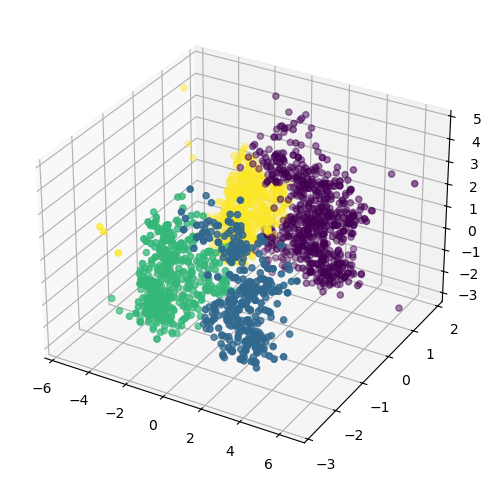

In [84]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

## Characterization of Clusters

In [94]:


X["cluster"] = labels_agg

In [95]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Couple/Single_Couple,Couple/Single_Single,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,0.0,1.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,1.0,0.0,0.0,0.0,1.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,1.0,0.0,0.0,1.0,0.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,1.0,0.0,0.0,1.0,0.0,3
4,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,0.0,1.0,0.0,1.0,0.0,3


<Axes: xlabel='cluster', ylabel='count'>

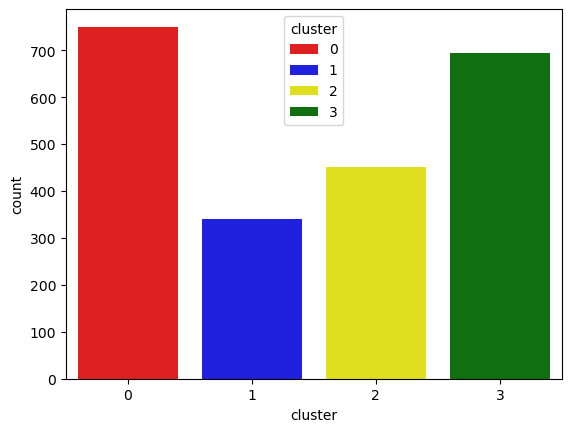

In [96]:
# Plots 
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

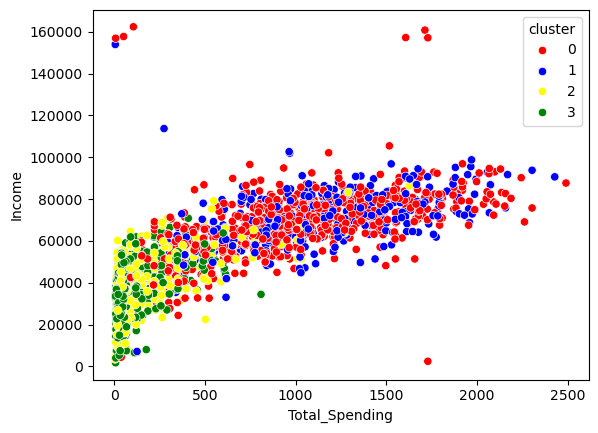

In [97]:
# Income and Spending Pattern
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [91]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Couple/Single', 'labels', 'cluster'],
      dtype='object')

In [98]:
# Cluster Summary 

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        67291.757333  49.062667           2.460000         5.625333   
1        70458.914706  50.088235           1.908824         5.761765   
2        38551.119734  48.669623           2.465632         2.855876   
3        35042.648921  48.988489           2.294964         2.408633   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.532000           8.021333           4.153333  0.006667   
1                   5.055882           8.314706           3.682353  0.005882   
2                   0.935698           3.893570           6.443459  0.011086   
3                   0.597122           3.395683           6.647482  0.011511   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

## Conclusion

Profiling the 4 clusters by average feature values reveals two clear axes: **income/spending level** and **household size**:

- **Cluster 1 — High-value singles:** highest income (~£70k), highest total spending (~£1,111), fewest children, and by far the highest campaign response rate (35%). The most valuable segment to target with premium offers.
- **Cluster 0 — High-value couples:** similar income (~£67k) and spending (~£969) to Cluster 1, but in a couple household; second-highest response rate (14%).
- **Cluster 2 — Budget-conscious, larger households (single):** lower income (~£38.5k), much lower spending (~£175), more children, and the most web visits — price-sensitive, browse-heavy shoppers.
- **Cluster 3 — Budget-conscious, larger households (couple):** lowest income (~£35k) and lowest spending (~£105) of all groups, with the lowest campaign response (7%) — the hardest segment to convert.

**Business takeaway:** marketing spend is best directed at Clusters 0 and 1 (higher income, higher response), while Clusters 2 and 3 may respond better to value-oriented promotions rather than premium campaigns.
